# Step 1: Imports & Loads


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

deliveries = pd.read_csv("deliveries.csv")
routes = pd.read_csv("routes.csv")

print("Deliveries Rows:", len(deliveries))
print("Routes Rows:", len(routes))

deliveries.head()

Deliveries Rows: 13
Routes Rows: 4


,record_id,month,route_id,hub,promised_days,actual_days
0,1,Jan,R1,Mumbai,2,2
1,2,Jan,R2,Chennai,3,4
2,3,Jan,R3,Delhi,5,8
3,4,Jan,R4,Mumbai,6,10
4,5,Feb,R1,Chennai,2,5


# Step 2: Confirm Numeric Types

In [2]:
deliveries["promised_days"] = pd.to_numeric(
    deliveries["promised_days"]
)

deliveries["actual_days"] = pd.to_numeric(
    deliveries["actual_days"]
)

print(deliveries.dtypes)

record_id         int64
month            object
route_id         object
hub              object
promised_days     int64
actual_days       int64
dtype: object


# Step 3: Remove Duplicate Row

In [3]:
before_rows = len(deliveries)

deliveries_clean = deliveries.drop_duplicates()

after_rows = len(deliveries_clean)

print("Before Row Count:", before_rows)
print("After Row Count:", after_rows)

assert after_rows == 12

Before Row Count: 13
After Row Count: 12


# Step 4: Merge Data

In [4]:
df = pd.merge(
    deliveries_clean,
    routes,
    on="route_id",
    how="left"
)

assert len(df) == 12
assert df["service_type"].isna().sum() == 0

df.head()

,record_id,month,route_id,hub,promised_days,actual_days,route,service_type
0,1,Jan,R1,Mumbai,2,2,Metro Link,Express
1,2,Jan,R2,Chennai,3,4,City Dash,Express
2,3,Jan,R3,Delhi,5,8,Highway Freight,Standard
3,4,Jan,R4,Mumbai,6,10,Rural Feeder,Standard
4,5,Feb,R1,Chennai,2,5,Metro Link,Express


# Step 5: Create delay_days

In [5]:
df["delay_days"] = np.maximum(
    df["actual_days"] - df["promised_days"],
    0
)

df.head()

,record_id,month,route_id,hub,promised_days,actual_days,route,service_type,delay_days
0,1,Jan,R1,Mumbai,2,2,Metro Link,Express,0
1,2,Jan,R2,Chennai,3,4,City Dash,Express,1
2,3,Jan,R3,Delhi,5,8,Highway Freight,Standard,3
3,4,Jan,R4,Mumbai,6,10,Rural Feeder,Standard,4
4,5,Feb,R1,Chennai,2,5,Metro Link,Express,3


# Step 6: Service-Type Summary

In [6]:
service_summary = (
    df.groupby("service_type")
      .agg(
          total_delay_days=("delay_days", "sum"),
          total_records=("record_id", "count"),
          delayed_shipments=(
              "delay_days",
              lambda x: (x > 0).sum()
          )
      )
      .reset_index()
)

service_summary["delay_incidence_rate_pct"] = (
    service_summary["delayed_shipments"]
    / service_summary["total_records"]
    * 100
).round(2)

service_summary

,service_type,total_delay_days,total_records,delayed_shipments,delay_incidence_rate_pct
0,Express,12,6,4,66.67
1,Standard,22,6,5,83.33


# Step 7: Route with Greatest Delay

In [7]:
route_summary = (
    df.groupby("route_id")["delay_days"]
      .sum()
      .reset_index()
)

top_route = route_summary.loc[
    route_summary["delay_days"].idxmax()
]

total_delay = df["delay_days"].sum()

delay_share = round(
    (top_route["delay_days"] / total_delay) * 100,
    2
)

print("Route with Greatest Delay:", top_route["route_id"])
print("Summed Delay Days:", top_route["delay_days"])
print("Share of Overall Delay:", delay_share, "%")

Route with Greatest Delay: R4
Summed Delay Days: 14
Share of Overall Delay: 41.18 %


# Step 8: Monthly Delay Chart

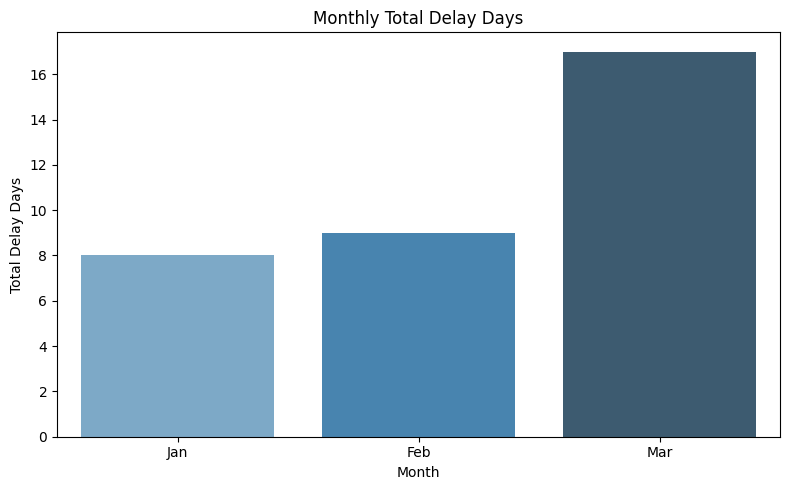

In [ ]:
month_order = ["Jan", "Feb", "Mar"]

monthly_delay = (
    df.groupby("month")["delay_days"]
      .sum()
      .reset_index()
)

monthly_delay["month"] = pd.Categorical(
    monthly_delay["month"],
    categories=month_order,
    ordered=True
)

monthly_delay = monthly_delay.sort_values("month")

plt.figure(figsize=(8,5))

sns.barplot(
data=monthly_delay,
x="month",
y="delay_days",
hue="month",
palette="Blues_d",
legend=False
)

plt.title("Monthly Total Delay Days")
plt.xlabel("Month")
plt.ylabel("Total Delay Days")

plt.tight_layout()

plt.show()

# Step 9: Export Files

In [13]:
df.to_csv(
    r"C:\Users\DEVANSHI\OneDrive\Desktop\DataAnalysis_SetA_10775\Output\clean_data.csv",
    index=False
)

service_summary.to_csv(
    r"C:\Users\DEVANSHI\OneDrive\Desktop\DataAnalysis_SetA_10775\Output\python_summary.csv",
    index=False
)

print("Exports completed successfully.")


Exports completed successfully.
